In [ ]:
# %load_ext watermark
# %watermark -a "Paul A. Wambo" -v -p Bio,matplotlib,numpy,pandas,pyMIBiG,seaborn,selfies,sklearn,transformers,torch,umap

In [ ]:
import os

import torch

import numpy as np
import pandas as pd
import seaborn as sns
# import selfies as sf
import matplotlib.pyplot as plt

# from Bio import SeqIO
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP

In [ ]:
# def weighted_pooling(embeddings, weights):
#     weights = weights / np.sum(weights)
#     return np.average(embeddings, axis=0, weights=weights)

# df["weight"] = df["expression_level"]

# bgc_embeddings = (
#     df.groupby("bgc_id")
#       .apply(lambda g: weighted_pooling(np.vstack(g.embedding), g.weight.values))
# )

# If you have protein-level metadata (domain importance, copy number, expression, confidence):

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
basepath = "/content/drive/MyDrive/criblage_biosciences/data/output"
saved_paths = [os.path.join(basepath, x) for x in os.listdir(basepath) if '35M' in x and x.endswith('.pkl')]

In [ ]:
import pickle as pkl

_df = []

for _, path in enumerate(saved_paths):
    with open(path, "rb") as f:
        _datum = pkl.load(f)
        _df.append(_datum)

df_embeddings = pd.concat(_df, ignore_index=True)
df_embeddings.head()

,bgc_id,protein_name,protein_id,protein_sequence,dna_sequence,embeddings,sequence,Biosynthetic Class,bgc_sequence
0,BGC0000001,orfP,AEK75490.1,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...,GTGACCGAGCTCGACCGGGCCTTCGACGCCGTACCGGCCCCGATCT...,"[[tensor(0.2849), tensor(0.0568), tensor(-0.03...",NaN,NaN,NaN
1,BGC0000001,None,AEK75491.1,MKPPASSVCPVDTSKMGNRSSPARYGRRPRKRCVELSETNLEFVHV...,GTGAAGCCGCCGGCCAGCTCTGTCTGCCCGGTGGACACCTCGAAGA...,"[[tensor(0.1528), tensor(-0.0032), tensor(0.20...",NaN,NaN,NaN
2,BGC0000001,abyR,AEK75492.1,MLGALRIADPAPRTITAPKVETLFATLLIRANHTVTTDELIAELWG...,TTGCTCGGAGCATTGCGGATCGCCGATCCCGCACCTCGCACGATTA...,"[[tensor(0.1949), tensor(0.0387), tensor(0.077...",NaN,NaN,NaN
3,BGC0000001,abyX,AEK75493.1,MTDVQLPAFPMTRTCPHQPPEGYAALRENGPLAQVRLVGDRTAWVV...,ATGACCGACGTCCAGCTGCCCGCGTTCCCGATGACCCGCACCTGTC...,"[[tensor(0.1594), tensor(0.0027), tensor(-0.01...",NaN,NaN,NaN
4,BGC0000001,abyH,AEK75494.1,MRDTAEHRIGTSGRHTPQAQATPADRLSQALARARSGRGGVVELVG...,GTGCGCGACACGGCAGAGCATCGGATCGGCACATCCGGGCGTCACA...,"[[tensor(0.2322), tensor(-0.0312), tensor(-0.0...",NaN,NaN,NaN


In [ ]:
bgc_df = (
    df_embeddings
    .groupby('bgc_id')['protein_sequence']
    .apply(list)
    .reset_index(name='sequence')
)

bgc_df.head()

,bgc_id,sequence
0,BGC0000001,[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...
1,BGC0000002,[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...
2,BGC0000003,[MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRN...
3,BGC0000004,[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...
4,BGC0000006,[MQSNKETALDPERNPTGEGEVRTSNDHDMLIDEAADASSHISGMK...


In [ ]:
def map_primary_class(s):
    s = s.lower()

    if "pks" in s and "nrps" in s:
        return "PKS-NRPS"
    if "pks" in s:
        return "PKS"
    if "nrps" in s:
        return "NRPS"
    if "ribosomal" in s:
        return "ribosomal"
    if "terpene" in s:
        return "terpene"
    if "saccharide" in s:
        return "saccharide"
    return "other"

In [ ]:
mibig_df = pd.read_parquet(os.path.join(basepath, '../databases/curated/mibig_db.parquet'))
mibig_df.head()

,Unnamed: 0,Code,Organism,Compounds,Biosynthetic Class,Completeness,Quality,Status,npaid,compound_id,...,original_journal_title,synonyms_dois,reassignment_dois,synthesis_dois,mibig_ids,gnps_ids,cmmc_ids,npmrd_id,npatlas_url,canonical_smiles
0,0,BGC0000034,Streptomyces sp. FR-008,candicidin,"NRPS, PKS",unknown,questionable,active,None,NaN,...,None,None,None,None,None,None,None,None,None,None
1,1,BGC0000064,Fusarium verticillioides,"fusarin C, dihydrofusarin C, fusarin D, epi-fu...","NRPS, PKS",unknown,questionable,active,None,NaN,...,None,None,None,None,None,None,None,None,None,None
2,2,BGC0000081,Streptoalloteichus sp. ATCC 53650,kedarcidin,"NRPS, PKS",complete,questionable,active,NPA020328,20328.0,...,Journal of the American Chemical Society,[],"[{'reference_doi': '10.1021/ja071205b', 'struc...",[],BGC0000081,[],[],NP0139110,https://www.npatlas.org/explore/compounds/NPA0...,COc1c(OC(C)C)cc2cc(O)c(C(=O)NC3Cc4ccc(c(Cl)n4)...
3,3,BGC0000145,Salinispora tropica,salinosporamide A,"NRPS, PKS",unknown,questionable,active,NPA011013,11013.0,...,Angewandte Chemie International Edition,[],[],"['10.1021/ja0522783', '10.1021/ol0508734', '10...",BGC0000145,['CCMSLIB00005721043%Salinosporamide A%3'],[],NP0004529,https://www.npatlas.org/explore/compounds/NPA0...,C[C@@]12OC(=O)[C@]1([C@@H](O)[C@@H]1C=CCCC1)NC...
4,4,BGC0000150,Salinispora tropica CNB-440,"sporolide A, sporolide B","NRPS, PKS",complete,questionable,active,NPA007130,7130.0,...,Organic Letters,[],[],"['10.1021/ja1048994', '10.1002/anie.200901894'...",BGC0000150,[],[],NP0005893,https://www.npatlas.org/explore/compounds/NPA0...,CO[C@H]1C(=O)OC[C@H](O)c2cc(Cl)c3c(c2)[C@@]24O...


In [ ]:
bgc_df = bgc_df.merge(
    mibig_df[['Code', 'Biosynthetic Class']],
    left_on='bgc_id',
    right_on='Code',
    how='left'
).drop(columns=['Code'])

In [ ]:
bgc_df["bgc_sequence"] = bgc_df["sequence"].apply(
    lambda seqs: " [SEP] ".join(seqs)
)

bgc_df.head()

,bgc_id,sequence,Biosynthetic Class,bgc_sequence
0,BGC0000001,[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,PKS,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...
1,BGC0000001,[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,PKS,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...
2,BGC0000002,[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,PKS,MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQL...
3,BGC0000003,[MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRN...,PKS,MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRNV...
4,BGC0000004,[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,PKS,MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPRI...


In [ ]:
model_name = "facebook/esm2_t12_35M_UR50D"  # "facebook/esm2_t33_650M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model = AutoModel.from_pretrained(model_name)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
model.to(device)

EsmModel(
  (embeddings): EsmEmbeddings(
    (word_embeddings): Embedding(33, 480, padding_idx=1)
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): EsmEncoder(
    (layer): ModuleList(
      (0-11): 12 x EsmLayer(
        (attention): EsmAttention(
          (self): EsmSelfAttention(
            (query): Linear(in_features=480, out_features=480, bias=True)
            (key): Linear(in_features=480, out_features=480, bias=True)
            (value): Linear(in_features=480, out_features=480, bias=True)
            (rotary_embeddings): RotaryEmbedding()
          )
          (output): EsmSelfOutput(
            (dense): Linear(in_features=480, out_features=480, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
          (LayerNorm): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        )
        (intermediate): EsmIntermediate(
          (dense): Linear(in_features=480, out_features=1920, bias=True)
        )
        (output): EsmOutput(
      

In [ ]:
proteins = bgc_df['bgc_sequence']

In [ ]:
MAX_LEN_PROT = 1024   # typical max for ESM2 small models
STRIDE = 128          # overlap for chunking

def chunk_sequence(seq, size=1022):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

In [ ]:
from tqdm import tqdm

def process_chunk(df_chunk, chunk_id):
    embeddings = []

    for i, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc=f"Chunk {chunk_id}"):
        seq = row["bgc_sequence"]
        chunk_vecs = []

        for chunk in chunk_sequence(seq):        # non-overlapping
            tokens = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LEN_PROT
            )
            tokens = {k: v.to(device) for k, v in tokens.items()}

            with torch.no_grad():
                out = model(**tokens)

                # CLS token embedding
                vec = out.last_hidden_state[:, 0, :].squeeze(0)

                # normalize
                vec = vec / vec.norm(p=2)

                chunk_vecs.append(vec.cpu())

        # === average chunk embeddings ===
        final_vec = torch.stack(chunk_vecs).mean(dim=0).numpy()

        embeddings.append(final_vec)

    df_chunk = df_chunk.copy()
    df_chunk["embeddings"] = embeddings

    save_path = os.path.join(basepath, f"BGCs_MiBIG_{chunk_id}_embeddings_35M_v2.pkl")
    df_chunk.to_pickle(save_path)

    return save_path

In [ ]:
import math

num_chunks = 10
chunk_size = math.ceil(len(bgc_df) / num_chunks)

df_chunks = [
    bgc_df.iloc[i:i+chunk_size]
    for i in range(0, len(bgc_df), chunk_size)
]

In [ ]:
saved_paths = []

for chunk_id, df_chunk in enumerate(df_chunks):
    print(f"Processing chunk {chunk_id}...")
    path = process_chunk(df_chunk, chunk_id)
    # path = os.path.join(SAVE_DIR, f"bgc_chunk_{chunk_id}.pkl")
    saved_paths.append(path)

Processing chunk 0...


Chunk 0: 100%|██████████| 359/359 [05:14<00:00,  1.14it/s]


Processing chunk 1...


Chunk 1: 100%|██████████| 359/359 [02:33<00:00,  2.34it/s]


Processing chunk 2...


...

Chunk 7: 100%|██████████| 359/359 [02:28<00:00,  2.41it/s]


Processing chunk 8...


Chunk 8: 100%|██████████| 359/359 [03:03<00:00,  1.95it/s]


Processing chunk 9...


Chunk 9: 100%|██████████| 353/353 [03:21<00:00,  1.75it/s]


In [ ]:
import pickle as pkl

_df = []

for _, path in enumerate(saved_paths):
    with open(path, "rb") as f:
        _datum = pkl.load(f)
        _df.append(_datum)

df_embeddings = pd.concat(_df, ignore_index=True)
df_embeddings.head()

,bgc_id,sequence,Biosynthetic Class,bgc_sequence,embeddings
0,BGC0000001,[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,PKS,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...,"[0.01585163, -0.013525647, -0.014134707, 0.009..."
1,BGC0000001,[MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRA...,PKS,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...,"[0.01585163, -0.013525647, -0.014134707, 0.009..."
2,BGC0000002,[MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQ...,PKS,MVVSGSVHPLLETVNLMLDRAVIDALFPADLPEPAHWEQRYPVRQL...,"[0.009741185, -0.018802002, -0.010233938, 0.00..."
3,BGC0000003,[MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRN...,PKS,MDPQQRLLLETTYEALENAGIPQANTNGSNTSVHVAMFTRDYDRNV...,"[-0.0057094945, -0.02960138, 0.0037824563, 0.0..."
4,BGC0000004,[MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPR...,PKS,MLIDEAADASSHISGMKLYLIVLSLLLAVFCVALDNTILSVAIPRI...,"[-0.0033033814, -0.026985243, -0.0033533326, 0..."


In [ ]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v  # leave zero-vectors unchanged
    return v / norm

In [ ]:
def run_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    return X_pca

In [ ]:
def run_umap(X, n_neighbors=15):
    umap_model = UMAP(random_state=42, metric='cosine', low_memory=True, densmap=True, n_neighbors=n_neighbors)
    X_umap = umap_model.fit_transform(X)
    return X_umap

In [ ]:
df_embeddings['embeddings_normalized'] = df_embeddings['embeddings'].apply(normalize)

In [ ]:
df_embeddings['primary_class'] = df_embeddings['Biosynthetic Class'].apply(map_primary_class)

In [ ]:
# X_pca = run_pca(np.vstack(bgc_df['protein_embedding_normalized'].values))
X = np.vstack(df_embeddings['embeddings_normalized'].values)
# X_pca = run_pca(X)
X_umap = run_umap(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
X.shape

(3584, 480)

<Axes: >

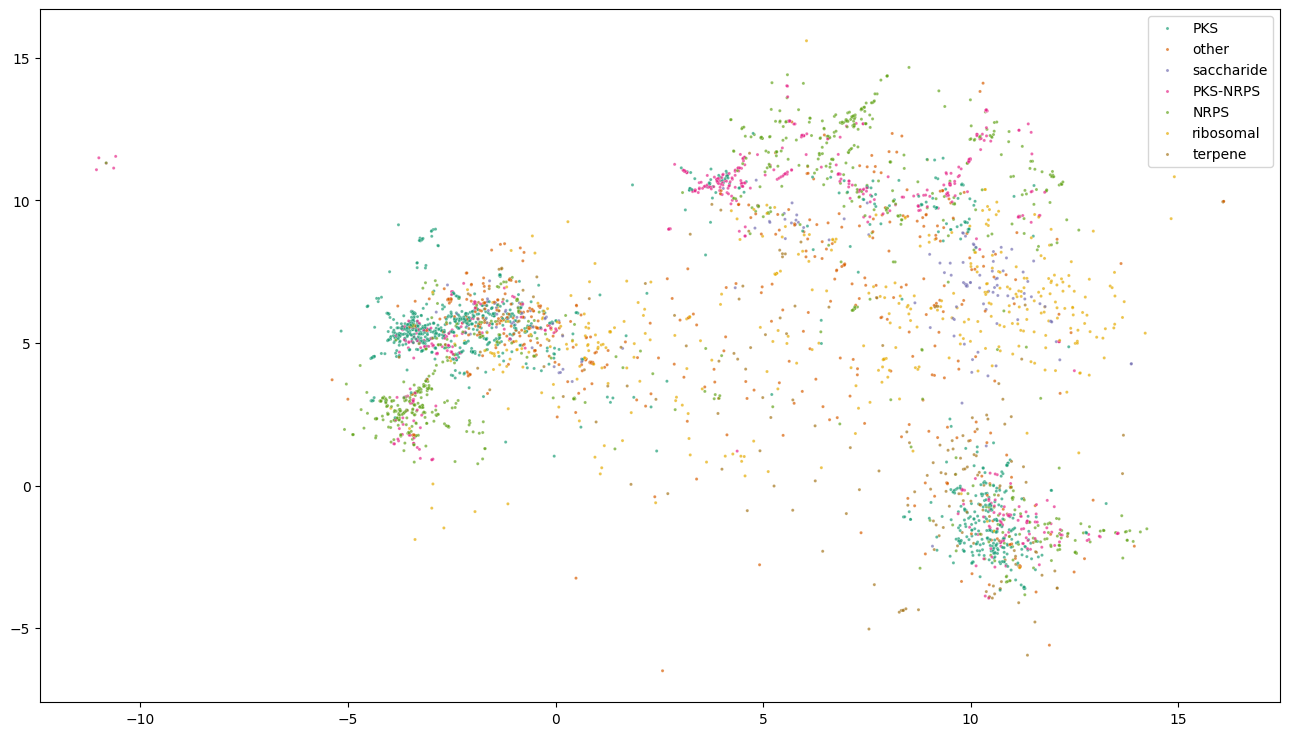

In [ ]:
### Plot Protein Embeddings UMAP
plt.figure(figsize=(16, 9))
sns.scatterplot(
    x=X_umap[:, 0],
    y=X_umap[:, 1],
    hue=df_embeddings['primary_class'].values,
    palette='Dark2',
    s=5,
    alpha=0.7
)

In [ ]:
projected_subset = pd.DataFrame({
    'UMAP_1': X_umap[:, 0],
    'UMAP_2': X_umap[:, 1],
    'labels': df_embeddings['primary_class'].values
})

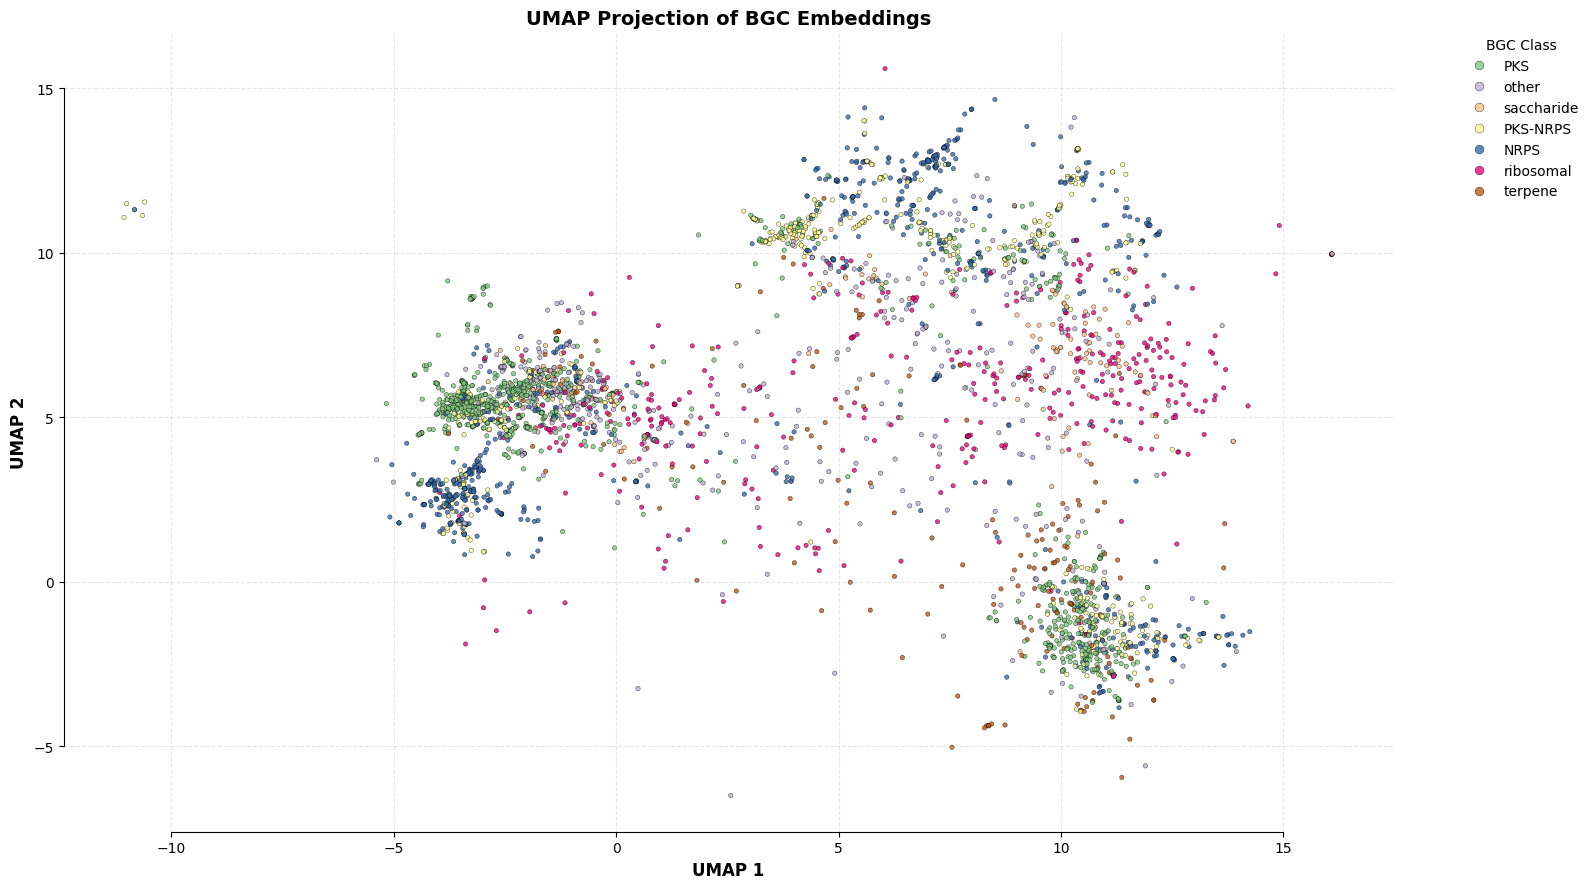

In [ ]:
plt.figure(figsize=(16, 9))

ax = sns.scatterplot(
    data=projected_subset,
    x='UMAP_1',
    y='UMAP_2',
    hue='labels',
    palette='Accent',
    s=10,           # smaller dots in the plot
    alpha=0.8,
    edgecolor='k',
    linewidth=0.3
)

# Legend with larger markers
ax.legend(
    title='BGC Class',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False,
    fontsize=10,
    markerscale=2  # multiply legend marker size by 2
)

ax.set_xlabel('UMAP 1', fontsize=12, weight='bold')
ax.set_ylabel('UMAP 2', fontsize=12, weight='bold')
ax.set_title('UMAP Projection of BGC Embeddings', fontsize=14, weight='bold')
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine(trim=True)
plt.tight_layout()
plt.show()
